# Project 02 — Student Performance Analysis
**Pluto Academy Data Analytics Internship**

Run all cells after placing `StudentsPerformance.csv` in `data/`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA = Path("../data")
OUT = Path("../outputs")
OUT.mkdir(exist_ok=True)

df = pd.read_csv(DATA/"StudentsPerformance.csv")
display(df.head())
print("Shape:", df.shape)
display(df.info())
display(df.isna().sum())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape: (1000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


None

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## 1. Five-line dataset summary

In [3]:
print(f"1. The dataset contains {df.shape[0]} student records and {df.shape[1]} columns.")
print("2. The dataset contains demographic and academic performance information.")
print("3. The academic performance variables are math, reading, and writing scores.")
print("4. The dataset also includes parental education and test preparation information.")
print("5. There are no missing values in any of the 8 columns.")

1. The dataset contains 1000 student records and 8 columns.
2. The dataset contains demographic and academic performance information.
3. The academic performance variables are math, reading, and writing scores.
4. The dataset also includes parental education and test preparation information.
5. There are no missing values in any of the 8 columns.


## 2. Data Exploration and Cleaning

### Cleaning Decisions

- The dataset contains 1,000 student records and 8 columns.
- No missing values were found in any column.
- The three score columns are stored as integers.
- The five demographic/category columns are stored as text.
- No missing-value replacement was required.
- No duplicate removal was required unless duplicate records are identified during further checking.
- The original dataset values are retained for analysis.

In [4]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [5]:
score_columns = ["math score", "reading score", "writing score"]

display(df[score_columns].describe())

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
for column in score_columns:
    print(
        f"{column}: "
        f"Minimum = {df[column].min()}, "
        f"Maximum = {df[column].max()}"
    )

math score: Minimum = 0, Maximum = 100
reading score: Minimum = 17, Maximum = 100
writing score: Minimum = 10, Maximum = 100


### Cleaning Result

The dataset contains 1,000 student records and 8 columns. No missing values or duplicate rows were found. The three academic score columns contain numeric values, while the demographic and preparation-related columns contain categorical text values. The score ranges were checked before beginning the analysis, and no invalid score values were identified.

## 3. Factor Analysis

### Question 1: Does parental education level affect scores?

To investigate this question, student scores are compared across different parental education levels. The analysis uses average scores and a box plot to examine differences in score distributions.

In [7]:
education_scores = (
    df.groupby("parental level of education")[
        ["math score", "reading score", "writing score"]
    ]
    .mean()
    .round(2)
)

display(education_scores)

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


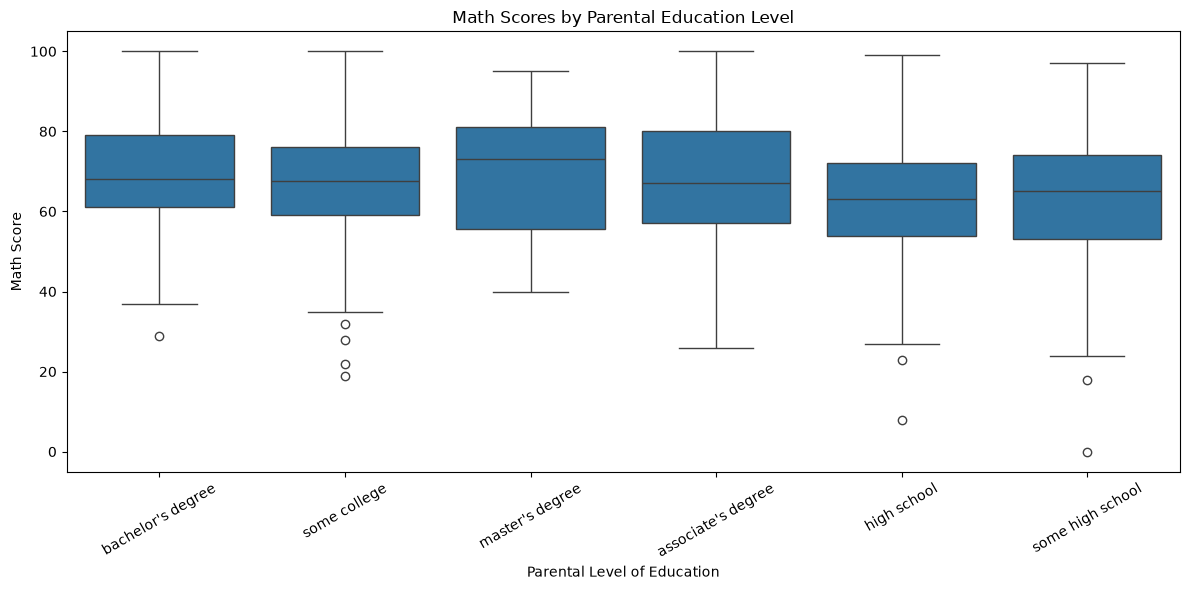

In [8]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="parental level of education",
    y="math score"
)

plt.title("Math Scores by Parental Education Level")
plt.xlabel("Parental Level of Education")
plt.ylabel("Math Score")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(OUT / "parental_education_math_scores_boxplot.png", dpi=300)
plt.show()

In [9]:
education_scores["overall average"] = education_scores[
    ["math score", "reading score", "writing score"]
].mean(axis=1).round(2)

display(
    education_scores.sort_values(
        "overall average",
        ascending=False
    )
)

,math score,reading score,writing score,overall average
parental level of education,,,,
master's degree,69.75,75.37,75.68,73.60
bachelor's degree,69.39,73.00,73.38,71.92
associate's degree,67.88,70.93,69.90,69.57
some college,67.13,69.46,68.84,68.48
some high school,63.50,66.94,64.89,65.11
high school,62.14,64.70,62.45,63.10


### Finding

Student performance varies across parental education levels in this dataset. The highest overall average score is observed among students whose parents have a master's degree (73.60), followed by bachelor's degree (71.92). The lowest overall average is observed among students whose parents have a high-school education (63.10). The box plot also shows differences in the distribution of math scores across parental education groups.

These results indicate an association between parental education level and student performance, but they do not establish that parental education directly causes differences in scores.

## Question 2: Do students who complete the test preparation course score higher?

This analysis compares the academic scores of students who completed the test preparation course with those who did not.

In [10]:
prep_scores = (
    df.groupby("test preparation course")[
        ["math score", "reading score", "writing score"]
    ]
    .mean()
    .round(2)
)

display(prep_scores)

,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


In [11]:
prep_scores["overall average"] = prep_scores[
    ["math score", "reading score", "writing score"]
].mean(axis=1).round(2)

display(prep_scores)

,math score,reading score,writing score,overall average
test preparation course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


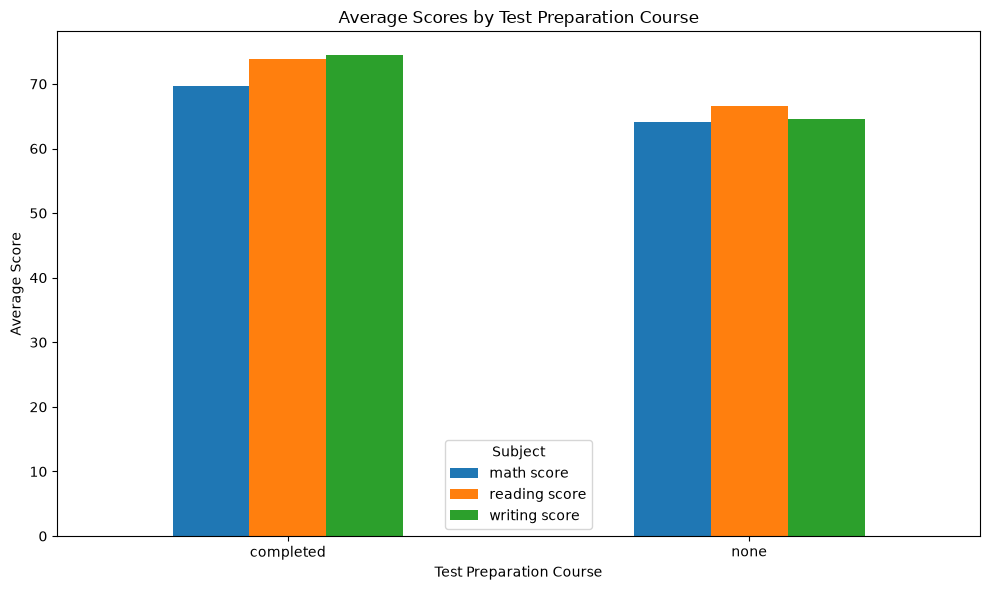

In [12]:
prep_plot = prep_scores[
    ["math score", "reading score", "writing score"]
]

ax = prep_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Average Scores by Test Preparation Course")
ax.set_xlabel("Test Preparation Course")
ax.set_ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.tight_layout()

plt.savefig(
    OUT / "test_preparation_average_scores.png",
    dpi=300
)

plt.show()

### Finding

Students who completed the test preparation course have higher average scores across all three subjects in this dataset. Their overall average score is 72.67, compared with 65.04 for students who did not complete the course, a difference of 7.63 points.

The completed group also has higher average math, reading, and writing scores. This indicates a positive association between test preparation completion and student performance in this dataset; however, the analysis alone does not establish causation.

## Question 3: Is there a strong relationship between reading and writing scores?

The relationship between reading and writing performance is examined using correlation analysis and a heatmap of the three academic score variables.

In [13]:
score_correlations = df[
    ["math score", "reading score", "writing score"]
].corr().round(2)

display(score_correlations)

,math score,reading score,writing score
math score,1.00,0.82,0.80
reading score,0.82,1.00,0.95
writing score,0.80,0.95,1.00


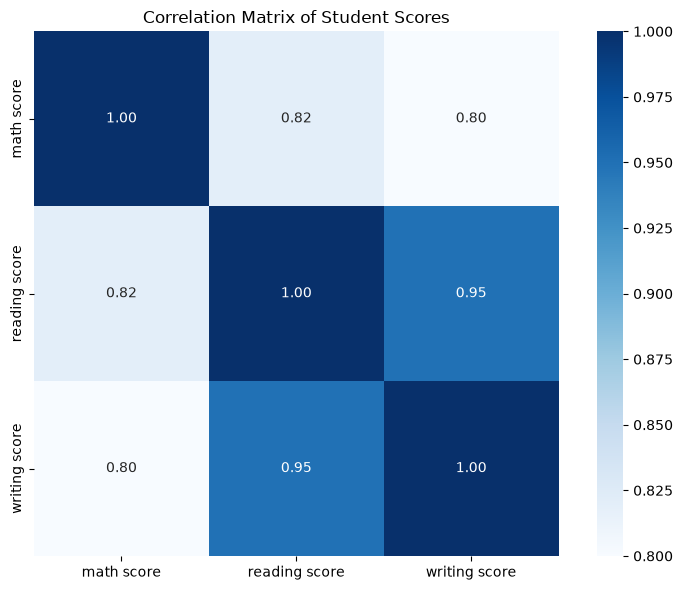

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    score_correlations,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Student Scores")
plt.tight_layout()

plt.savefig(
    OUT / "score_correlation_heatmap.png",
    dpi=300
)

plt.show()

### Finding

The three academic scores show strong positive relationships with one another. The strongest correlation is between reading and writing scores (0.95), indicating that students with higher reading scores generally tend to have higher writing scores. Math also has strong positive correlations with reading (0.82) and writing (0.80).

The results show strong associations between the subjects, but correlation alone does not establish a causal relationship.

## Question 4: Do male and female students perform differently across subjects?

This analysis compares the average math, reading, and writing scores of male and female students.

In [15]:
gender_scores = (
    df.groupby("gender")[
        ["math score", "reading score", "writing score"]
    ]
    .mean()
    .round(2)
)

display(gender_scores)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


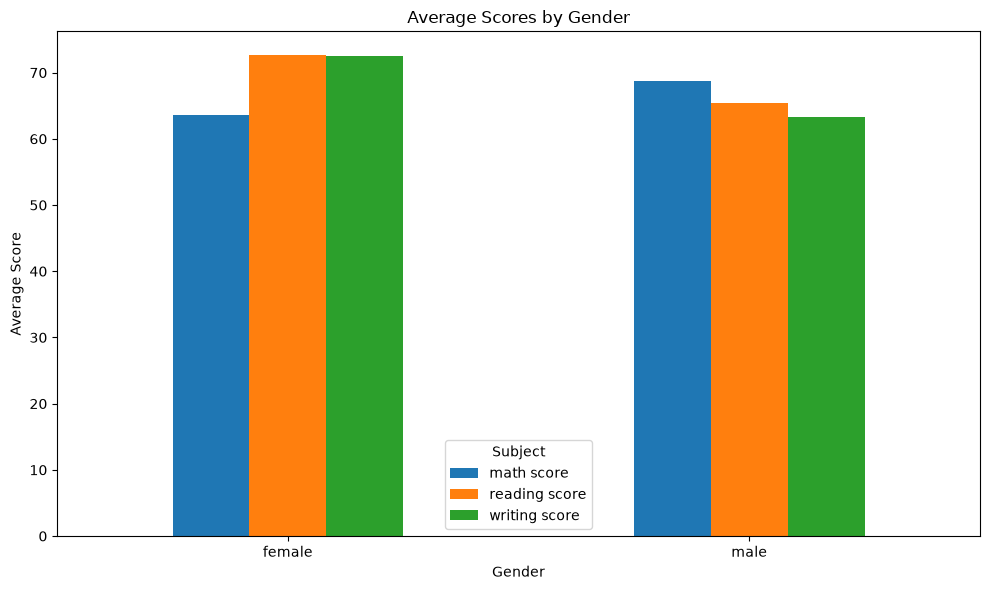

In [16]:
ax = gender_scores.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Average Scores by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.tight_layout()

plt.savefig(
    OUT / "gender_subject_scores.png",
    dpi=300
)

plt.show()

### Finding

Average performance differs by subject across the gender groups in this dataset. Male students have a higher average math score (68.73) than female students (63.63). In contrast, female students have higher average reading (72.61) and writing (72.47) scores than male students (65.47 and 63.31 respectively).

The results therefore show different performance patterns across subjects rather than a consistent difference in one direction across all three subjects.

## Question 5: How are total scores distributed?

A total score is calculated by adding each student's math, reading, and writing scores. The distribution of total scores is then examined using descriptive statistics and a histogram.

In [17]:
df["total score"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
)

display(df["total score"].describe().round(2))

count    1000.00
mean      203.31
std        42.77
min        27.00
25%       175.00
50%       205.00
75%       233.00
max       300.00
Name: total score, dtype: float64

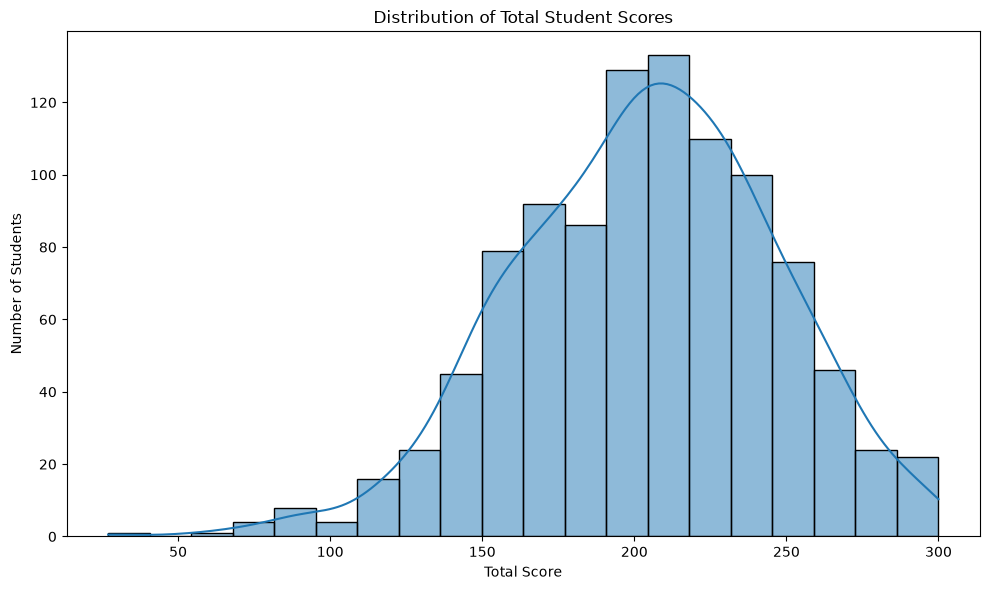

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="total score",
    bins=20,
    kde=True
)

plt.title("Distribution of Total Student Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")
plt.tight_layout()

plt.savefig(
    OUT / "total_score_distribution.png",
    dpi=300
)

plt.show()

### Finding

The total scores range from 27 to 300, with an average of 203.31 and a median of 205. The histogram shows that scores are concentrated mainly around the middle and upper portion of the possible total-score range. The standard deviation of 42.77 indicates noticeable variation in student performance.

## Additional Visualisation: Reading vs Math Scores

A scatter plot is used to visualise the relationship between reading and math scores.

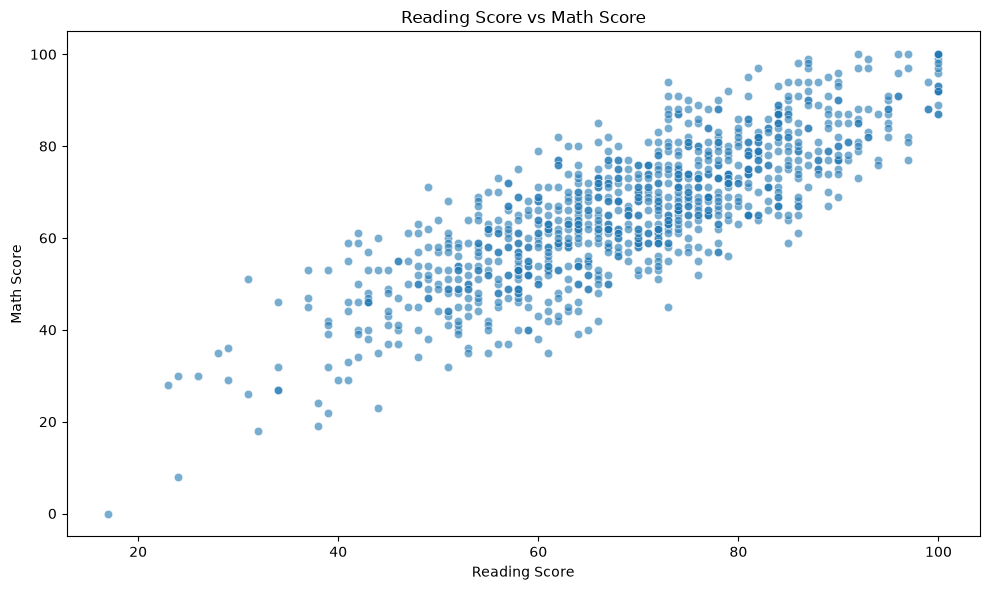

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="reading score",
    y="math score",
    alpha=0.6
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.tight_layout()

plt.savefig(
    OUT / "reading_vs_math_scatter.png",
    dpi=300
)

plt.show()

## 4. At-Risk Student Segmentation

### Definition

A student is classified as **at-risk** if they score below 50 in at least one of the three subjects: math, reading, or writing.

This threshold is used to identify students who may need additional academic support.

In [20]:
df["at_risk"] = (
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50)
)

print("Total students:", len(df))
print("At-risk students:", df["at_risk"].sum())
print(
    "At-risk percentage:",
    round(df["at_risk"].mean() * 100, 2),
    "%"
)

Total students: 1000
At-risk students: 188
At-risk percentage: 18.8 %


In [21]:
gender_risk = (
    df.groupby("gender")["at_risk"]
    .agg(
        at_risk_students="sum",
        total_students="count"
    )
)

gender_risk["at_risk_percentage"] = (
    gender_risk["at_risk_students"]
    / gender_risk["total_students"] * 100
).round(2)

display(gender_risk)

,at_risk_students,total_students,at_risk_percentage
gender,,,
female,89,518,17.18
male,99,482,20.54


In [22]:
education_risk = (
    df.groupby("parental level of education")["at_risk"]
    .agg(
        at_risk_students="sum",
        total_students="count"
    )
)

education_risk["at_risk_percentage"] = (
    education_risk["at_risk_students"]
    / education_risk["total_students"] * 100
).round(2)

display(
    education_risk.sort_values(
        "at_risk_percentage",
        ascending=False
    )
)

,at_risk_students,total_students,at_risk_percentage
parental level of education,,,
some high school,46,179,25.70
high school,49,196,25.00
some college,38,226,16.81
associate's degree,33,222,14.86
bachelor's degree,16,118,13.56
master's degree,6,59,10.17


In [23]:
prep_risk = (
    df.groupby("test preparation course")["at_risk"]
    .agg(
        at_risk_students="sum",
        total_students="count"
    )
)

prep_risk["at_risk_percentage"] = (
    prep_risk["at_risk_students"]
    / prep_risk["total_students"] * 100
).round(2)

display(
    prep_risk.sort_values(
        "at_risk_percentage",
        ascending=False
    )
)

,at_risk_students,total_students,at_risk_percentage
test preparation course,,,
none,152,642,23.68
completed,36,358,10.06


In [24]:
prep_risk = (
    df.groupby("test preparation course")["at_risk"]
    .agg(
        at_risk_students="sum",
        total_students="count"
    )
)

prep_risk["at_risk_percentage"] = (
    prep_risk["at_risk_students"]
    / prep_risk["total_students"] * 100
).round(2)

display(prep_risk)

,at_risk_students,total_students,at_risk_percentage
test preparation course,,,
completed,36,358,10.06
none,152,642,23.68


### At-Risk Group Breakdown

The following tables compare the number and percentage of at-risk students across gender, parental education level, and test preparation status.

In [25]:
print("At-Risk Students by Gender")
display(gender_risk)

print("At-Risk Students by Parental Education")
display(
    education_risk.sort_values(
        "at_risk_percentage",
        ascending=False
    )
)

print("At-Risk Students by Test Preparation")
display(prep_risk)

At-Risk Students by Gender


,at_risk_students,total_students,at_risk_percentage
gender,,,
female,89,518,17.18
male,99,482,20.54


At-Risk Students by Parental Education


,at_risk_students,total_students,at_risk_percentage
parental level of education,,,
some high school,46,179,25.70
high school,49,196,25.00
some college,38,226,16.81
associate's degree,33,222,14.86
bachelor's degree,16,118,13.56
master's degree,6,59,10.17


At-Risk Students by Test Preparation


,at_risk_students,total_students,at_risk_percentage
test preparation course,,,
completed,36,358,10.06
none,152,642,23.68


### At-Risk Percentage by Parental Education

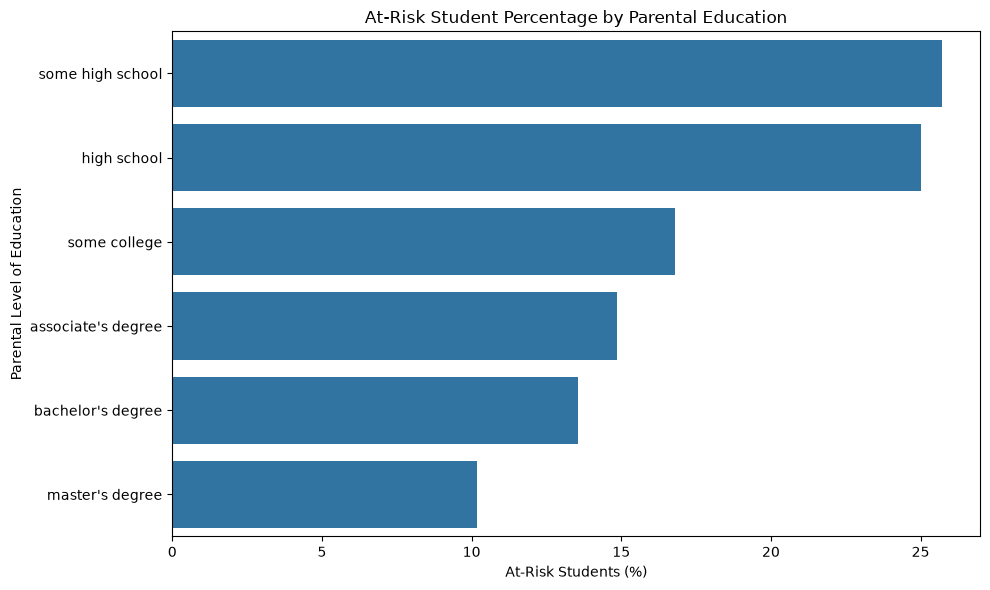

In [26]:
risk_education_plot = (
    education_risk
    .sort_values("at_risk_percentage", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=risk_education_plot["at_risk_percentage"],
    y=risk_education_plot.index
)

plt.title("At-Risk Student Percentage by Parental Education")
plt.xlabel("At-Risk Students (%)")
plt.ylabel("Parental Level of Education")
plt.tight_layout()

plt.savefig(
    OUT / "at_risk_by_parental_education.png",
    dpi=300
)

plt.show()

In [27]:
at_risk_summary = pd.DataFrame({
    "Total Students": [len(df)],
    "At-Risk Students": [df["at_risk"].sum()],
    "At-Risk Percentage": [round(df["at_risk"].mean() * 100, 2)]
})

display(at_risk_summary)

,Total Students,At-Risk Students,At-Risk Percentage
0,1000,188,18.8


In [28]:
highest_gender_risk = gender_risk["at_risk_percentage"].idxmax()
highest_education_risk = education_risk["at_risk_percentage"].idxmax()
highest_prep_risk = prep_risk["at_risk_percentage"].idxmax()

print(
    "Gender group with highest at-risk percentage:",
    highest_gender_risk
)

print(
    "Parental education group with highest at-risk percentage:",
    highest_education_risk
)

print(
    "Test preparation group with highest at-risk percentage:",
    highest_prep_risk
)

Gender group with highest at-risk percentage: male
Parental education group with highest at-risk percentage: some high school
Test preparation group with highest at-risk percentage: none


In [29]:
print("===== OVERALL AT-RISK SUMMARY =====")
print("Total students:", len(df))
print("At-risk students:", int(df["at_risk"].sum()))
print("At-risk percentage:", round(df["at_risk"].mean() * 100, 2), "%")


print("\n===== AT-RISK BY GENDER =====")
display(gender_risk)


print("\n===== AT-RISK BY PARENTAL EDUCATION =====")
display(
    education_risk.sort_values(
        "at_risk_percentage",
        ascending=False
    )
)


print("\n===== AT-RISK BY TEST PREPARATION =====")
display(prep_risk.sort_values(
    "at_risk_percentage",
    ascending=False
))

===== OVERALL AT-RISK SUMMARY =====
Total students: 1000
At-risk students: 188
At-risk percentage: 18.8 %

===== AT-RISK BY GENDER =====


,at_risk_students,total_students,at_risk_percentage
gender,,,
female,89,518,17.18
male,99,482,20.54



===== AT-RISK BY PARENTAL EDUCATION =====


,at_risk_students,total_students,at_risk_percentage
parental level of education,,,
some high school,46,179,25.70
high school,49,196,25.00
some college,38,226,16.81
associate's degree,33,222,14.86
bachelor's degree,16,118,13.56
master's degree,6,59,10.17



===== AT-RISK BY TEST PREPARATION =====


,at_risk_students,total_students,at_risk_percentage
test preparation course,,,
none,152,642,23.68
completed,36,358,10.06


## At-Risk Analysis — Key Finding

Students were classified as at-risk when they scored below 50 in at least one of the three subjects: math, reading, or writing.

The analysis compares at-risk percentages across gender, parental education level, and test preparation status. The groups with the highest observed at-risk percentages are identified to help target additional academic support.

### At-Risk Percentage by Test Preparation Course

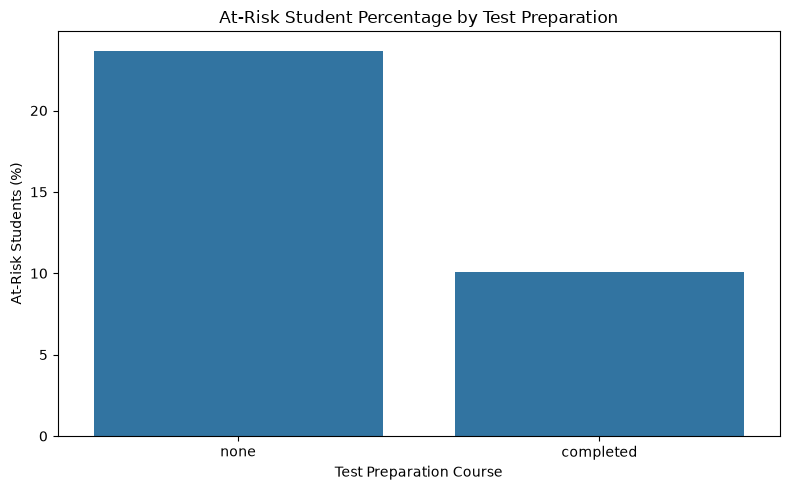

In [30]:
prep_plot = prep_risk.sort_values(
    "at_risk_percentage",
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=prep_plot.index,
    y=prep_plot["at_risk_percentage"]
)

plt.title("At-Risk Student Percentage by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("At-Risk Students (%)")

plt.tight_layout()

plt.savefig(
    OUT / "at_risk_by_test_preparation.png",
    dpi=300
)

plt.show()

# 10. Principal's Report

## Executive Summary

This analysis examined the academic performance of 1,000 students across mathematics, reading, and writing. The overall average scores were 66.09 in mathematics, 69.17 in reading, and 68.05 in writing. The analysis also examined differences in performance based on parental education, test preparation, and gender.

## Key Findings

### 1. Overall Academic Performance

The average total score was 203.31 out of 300.

Reading had the highest average score among the three subjects, while mathematics had the lowest average.

### 2. Parental Education

Students whose parents had a master's degree had an overall average score of 73.60.

Students whose parents had a high school education had an overall average score of 63.10.

The results show an association between parental education level and average student performance in this dataset.

### 3. Test Preparation

Students who completed the test preparation course had an overall average score of 72.67.

Students who did not complete the course had an overall average score of 65.04.

The at-risk percentage was 10.06% among students who completed the course compared with 23.68% among students who did not.

This is an observed association in the dataset and does not by itself establish causation.

### 4. Gender-Based Performance

Female students had higher average reading and writing scores.

Male students had a higher average mathematics score.

The average scores were:

| Gender | Math | Reading | Writing |
|---|---:|---:|---:|
| Female | 63.63 | 72.61 | 72.47 |
| Male | 68.73 | 65.47 | 63.31 |

### 5. At-Risk Students

Using the definition of scoring below 50 in at least one subject, 188 out of 1,000 students were identified as at-risk.

This represents 18.8% of the dataset.

The at-risk percentages were:

- Female: 17.18%
- Male: 20.54%
- Some high school parental education: 25.70%
- High school parental education: 25.00%
- Test preparation completed: 10.06%
- Test preparation not completed: 23.68%

## Recommendations

### Recommendation 1 — Targeted Academic Support

Provide additional academic support to students identified as at-risk, particularly in subjects where their scores fall below the defined threshold of 50. Regular progress checks can be used to identify whether their performance improves over time.

### Recommendation 2 — Expand Test Preparation Support

Increase awareness and access to test preparation resources for students who have not completed the preparation course. Schools can provide structured preparation sessions, practice assessments, and study resources.

### Recommendation 3 — Subject-Specific Support

Use subject-level performance patterns to provide targeted support. Students requiring mathematics support can receive additional mathematics practice, while reading and writing support can focus on comprehension, writing exercises, and regular assessments.

## Most Impactful Recommendation

The institution should strengthen early identification and targeted academic support for at-risk students. Students who score below 50 in at least one subject can be identified early and provided with additional practice and mentoring. Their progress should then be monitored through periodic assessments. This approach can help direct support toward students who show the greatest need based on the analysis.

## Conclusion

The analysis demonstrates how student performance data can be used to identify academic patterns and potential areas for intervention.

The findings can support data-informed academic planning and targeted student support.